In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src.dataset import CharTokenizer, split_data
from src.models import create_wavenet

# Create data sets
words = open("data/names.txt", "r").read().splitlines()
tokenizer = CharTokenizer(words)
vacab_size = len(tokenizer.itos)
block_size = 8
(Xtr, Ytr), (Xdev, Ydev), (Xtest, Ytest) = split_data(words, tokenizer, block_size)
print(f"Xtr: {Xtr.shape} Ytr {Ytr.shape}")

# Create model
g = torch.Generator().manual_seed(42)
model = create_wavenet(embedding_size=24, vacab_size=vacab_size, hidden_dim=128, generator=g)
print(f"Total params: {sum(p.nelement() for p in model.parameters())}") # number of parameters in total

Xtr: torch.Size([182778, 8]) Ytr torch.Size([182778])
Total params: 76579


In [3]:
# Verify the shape is correct
x_batch = Xtr[:4]
print(f"Input: {x_batch.shape}")
s = x_batch
for layer in model.layers:
    s = layer(s)
    print(f"{layer.__class__.__name__:20s} -> {tuple(s.shape)}")

Input: torch.Size([4, 8])
Embedding            -> (4, 8, 24)
FlattenConsecutive   -> (4, 4, 48)
Linear               -> (4, 4, 128)
BatchNorm1d          -> (4, 4, 128)
Tanh                 -> (4, 4, 128)
FlattenConsecutive   -> (4, 2, 256)
Linear               -> (4, 2, 128)
BatchNorm1d          -> (4, 2, 128)
Tanh                 -> (4, 2, 128)
FlattenConsecutive   -> (4, 256)
Linear               -> (4, 128)
BatchNorm1d          -> (4, 128)
Tanh                 -> (4, 128)
Linear               -> (4, 27)


In [4]:
batch_size = 64
max_steps = 200000

ud = [] # update to date ratio change history
lossi = [] #log loss change history

model.train()

for step in range(max_steps):
    # 1. select a random mini-batch from training data set
    batch_idxes = torch.randint(0, Xtr.shape[0], (batch_size,))

    # 2. prepare training data
    # x: (batch_size, block_size)
    # y: (batch_size,)
    x = Xtr[batch_idxes]
    y = Ytr[batch_idxes]

    # 3. forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    # 4. backward pass
    for layer in model.layers:
        layer.out.retain_grad() #Retain grad for non-leaf node, debug only
    for p in model.parameters():
        p.grad = None
    loss.backward()

    # 5. optimize with learning rate decay
    lr = 0.1 if step < 150000 else 0.01
    for p in model.parameters():
        p.data -= lr * p.grad

    # track stats
    if step % 10000 == 0: # print every once in a while
        print(f'{step:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append( [((lr*p.grad).std() / p.data.std()).log10().item() for p in model.parameters()])

    #if step >= 1000:
        #break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3039
  10000/ 200000: 2.2684
  20000/ 200000: 1.9625
  30000/ 200000: 1.8351
  40000/ 200000: 2.0726
  50000/ 200000: 1.8825
  60000/ 200000: 1.9359
  70000/ 200000: 2.0211
  80000/ 200000: 1.8471
  90000/ 200000: 1.7367
 100000/ 200000: 1.7171
 110000/ 200000: 1.7911
 120000/ 200000: 1.9452
 130000/ 200000: 2.1379
 140000/ 200000: 1.7751
 150000/ 200000: 1.5305
 160000/ 200000: 1.7017
 170000/ 200000: 1.4975
 180000/ 200000: 1.7203
 190000/ 200000: 1.5763


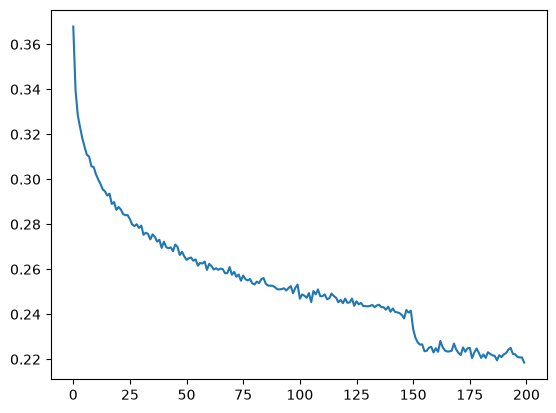

In [8]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [9]:
model.eval()

@torch.no_grad()
def evaluate_loss(X, Y):
    return F.cross_entropy(model(X), Y).item()

print(f"Dev Loss: {evaluate_loss(Xdev, Ydev):.4f}")
print(f"Test Loss: {evaluate_loss(Xtest, Ytest):.4f}")

Dev Loss: 2.2982
Test Loss: 2.3551


In [10]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(tokenizer.itos[i] for i in out)) # decode and print the generated word

sajah.
talan.
marieas.
elsey.
dailynrose.
whitte.
emiliana.
omeric.
antabella.
christal.
mahdie.
dilon.
alonni.
veralyn.
ryelynn.
miang.
marisa.
bejnali.
vianna.
azla.
